# Student Performance Prediction Using Machine Learning

## Project Objective

The objective of this project is to build machine learning models
that predict whether a student will pass or fail based on selected
student performance features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [3]:
data = {
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 2, 3,
                     5, 6, 7, 4, 8, 1, 3, 5, 6, 7],

    "attendance": [55, 60, 65, 70, 75, 80, 85, 90, 58, 68,
                   78, 82, 88, 72, 95, 50, 64, 76, 84, 89],

    "previous_score": [35, 40, 45, 50, 55, 60, 65, 75, 38, 48,
                       58, 63, 70, 52, 80, 30, 44, 57, 67, 73],

    "assignments_completed": [2, 3, 4, 5, 6, 7, 8, 9, 3, 4,
                              6, 7, 8, 5, 10, 1, 4, 6, 7, 9],

    "result": [0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
               1, 1, 1, 1, 1, 0, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

In [4]:
df

,study_hours,attendance,previous_score,assignments_completed,result
0,1,55,35,2,0
1,2,60,40,3,0
2,3,65,45,4,0
3,4,70,50,5,1
4,5,75,55,6,1
5,6,80,60,7,1
6,7,85,65,8,1
7,8,90,75,9,1
8,2,58,38,3,0
9,3,68,48,4,0


In [5]:
df.head()

,study_hours,attendance,previous_score,assignments_completed,result
0,1,55,35,2,0
1,2,60,40,3,0
2,3,65,45,4,0
3,4,70,50,5,1
4,5,75,55,6,1


In [6]:
df.tail()

,study_hours,attendance,previous_score,assignments_completed,result
15,1,50,30,1,0
16,3,64,44,4,0
17,5,76,57,6,1
18,6,84,67,7,1
19,7,89,73,9,1


In [7]:
df.shape

(20, 5)

In [8]:
df.columns

Index(['study_hours', 'attendance', 'previous_score', 'assignments_completed',
       'result'],
      dtype='object')

In [9]:
df.dtypes

study_hours              int64
attendance               int64
previous_score           int64
assignments_completed    int64
result                   int64
dtype: object

In [10]:
df.isnull().sum()

study_hours              0
attendance               0
previous_score           0
assignments_completed    0
result                   0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,study_hours,attendance,previous_score,assignments_completed,result
count,20.000000,20.0000,20.00000,20.000000,20.00000
mean,4.650000,74.2000,55.25000,5.700000,0.65000
std,2.230766,12.7428,14.07078,2.473012,0.48936
min,1.000000,50.0000,30.00000,1.000000,0.00000
25%,3.000000,64.7500,44.75000,4.000000,0.00000
50%,5.000000,75.5000,56.00000,6.000000,1.00000
75%,6.250000,84.2500,65.50000,7.250000,1.00000
max,8.000000,95.0000,80.00000,10.000000,1.00000


In [13]:
df["result"].value_counts()

result
1    13
0     7
Name: count, dtype: int64

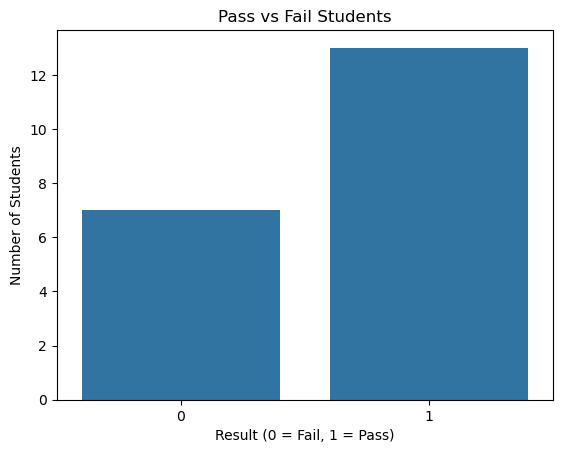

In [14]:
sns.countplot(x="result", data=df)

plt.title("Pass vs Fail Students")
plt.xlabel("Result (0 = Fail, 1 = Pass)")
plt.ylabel("Number of Students")

plt.show()

In [15]:
X = df[[
    "study_hours",
    "attendance",
    "previous_score",
    "assignments_completed"
]]

In [16]:
X.head()

,study_hours,attendance,previous_score,assignments_completed
0,1,55,35,2
1,2,60,40,3
2,3,65,45,4
3,4,70,50,5
4,5,75,55,6


In [17]:
y = df["result"]

In [18]:
y.head()

0    0
1    0
2    0
3    1
4    1
Name: result, dtype: int64

In [19]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20, 4)
y shape: (20,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (16, 4)
X_test : (4, 4)
y_train: (16,)
y_test : (4,)


In [22]:
scaler = StandardScaler()

In [23]:
X_train_scaled = scaler.fit_transform(X_train)

In [24]:
X_test_scaled = scaler.transform(X_test)

In [25]:
print(X_train_scaled)

[[-1.75291964 -1.89254909 -1.76132921 -1.66489132]
 [ 0.40451992  0.22229942  0.08938089  0.30831321]
 [ 0.40451992  0.41455837  0.34175044  0.30831321]
 [-0.67419986 -0.73899536 -0.75185098 -0.67828906]
 [ 0.40451992  0.60681733  0.67824319  0.30831321]
 [-1.21355975 -1.31577222 -1.25659009 -1.17159019]
 [-0.67419986 -0.5467364  -0.5836046  -0.67828906]
 [-1.21355975 -1.21964275 -1.17246691 -1.17159019]
 [-1.21355975 -0.93125431 -0.92009735 -1.17159019]
 [ 0.94387981  1.08746471  1.1829823   1.29491547]
 [-0.13483997 -0.25834797 -0.33123505 -0.18498792]
 [ 0.94387981  0.99133524  0.93061275  0.80161434]
 [ 1.4832397   1.18359419  1.35122868  1.29491547]
 [-0.13483997  0.03004046 -0.07886549 -0.18498792]
 [ 1.4832397   1.66424158  1.77184461  1.78821661]
 [ 0.94387981  0.7029468   0.50999682  0.80161434]]


In [26]:
model = LogisticRegression()

In [27]:
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [29]:
y_pred = model.predict(X_test_scaled)

print("Predicted:", y_pred)
print("Actual   :", y_test.values)

Predicted: [0 1 0 0]
Actual   : [0 1 0 0]


In [30]:
y_probability = model.predict_proba(X_test_scaled)

print(y_probability)

[[0.97721344 0.02278656]
 [0.10603944 0.89396056]
 [0.99146364 0.00853636]
 [0.91145877 0.08854123]]


In [31]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy:", accuracy * 100, "%")

Accuracy: 1.0
Accuracy: 100.0 %


In [32]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3 0]
 [0 1]]


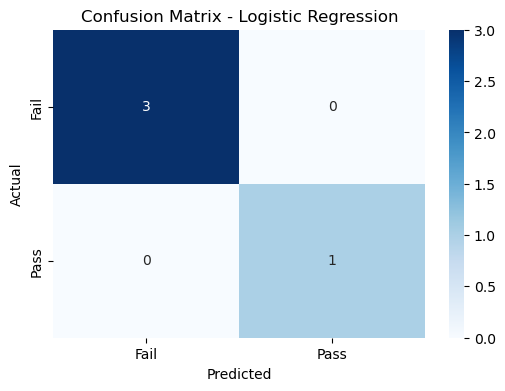

In [33]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [35]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

print("AUC:", auc)

AUC: 1.0


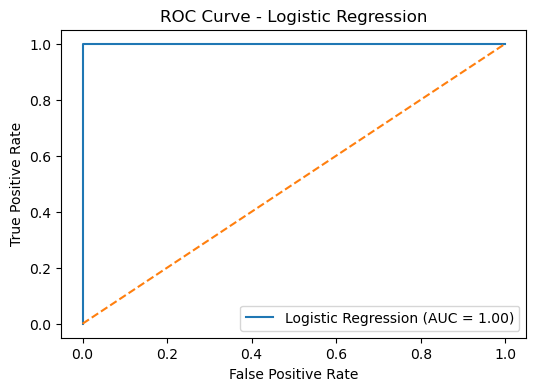

In [36]:
plt.figure(figsize=(6, 4))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

In [37]:
tree_model = DecisionTreeClassifier(random_state=42)


In [38]:
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [39]:
y_tree_pred = tree_model.predict(X_test)

print("Predicted:", y_tree_pred)
print("Actual   :", y_test.values)

Predicted: [0 1 0 0]
Actual   : [0 1 0 0]


In [40]:
tree_accuracy = accuracy_score(y_test, y_tree_pred)

print("Decision Tree Accuracy:", tree_accuracy)
print("Decision Tree Accuracy:", tree_accuracy * 100, "%")

Decision Tree Accuracy: 1.0
Decision Tree Accuracy: 100.0 %


In [41]:
tree_cm = confusion_matrix(y_test, y_tree_pred)

print(tree_cm)

[[3 0]
 [0 1]]


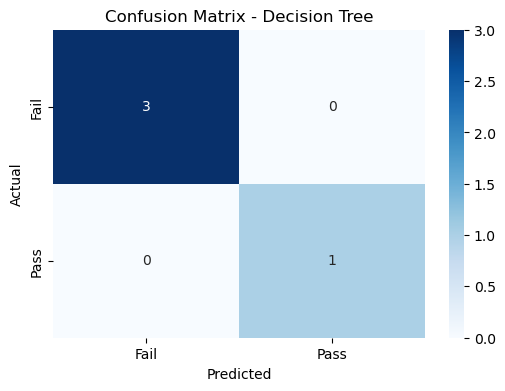

In [42]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [43]:
print(classification_report(y_test, y_tree_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



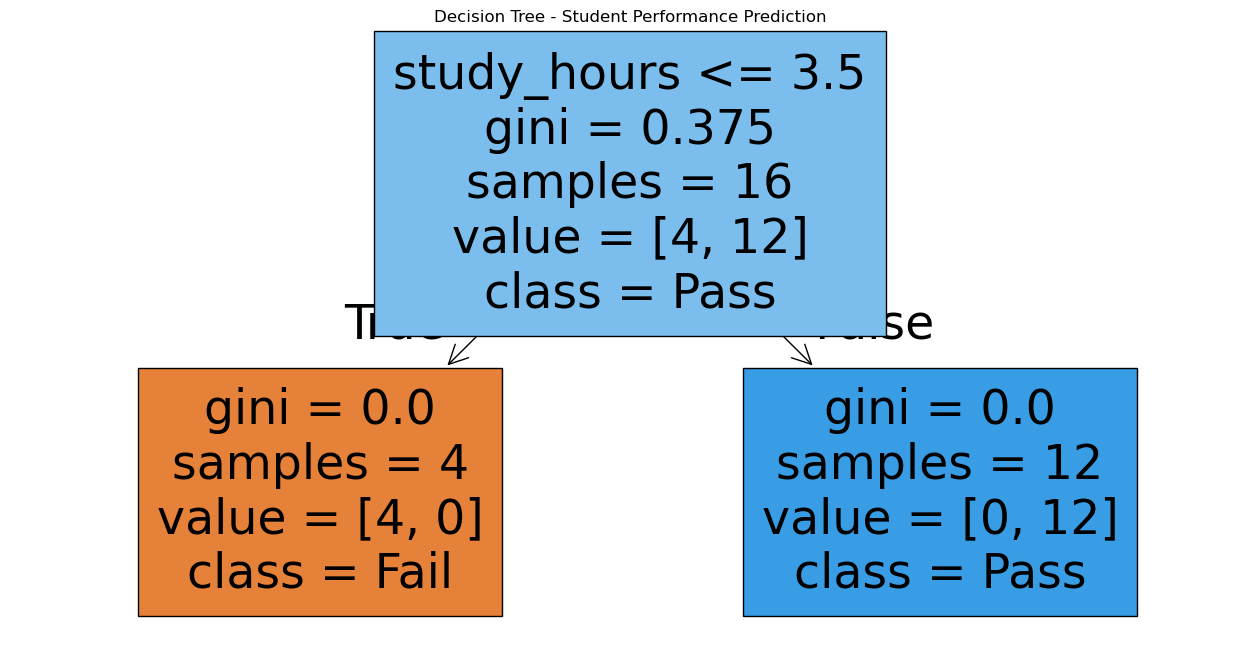

In [44]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True
)

plt.title("Decision Tree - Student Performance Prediction")
plt.show()

## Model Comparison

Two machine learning models were evaluated for Student Performance Prediction:

1. Logistic Regression
2. Decision Tree

Both models correctly predicted all 4 test samples and achieved an accuracy of 100%.

However, the test dataset contains only 4 samples, so these results should not be considered representative of real-world performance.

In [45]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, tree_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,1.0
1,Decision Tree,1.0


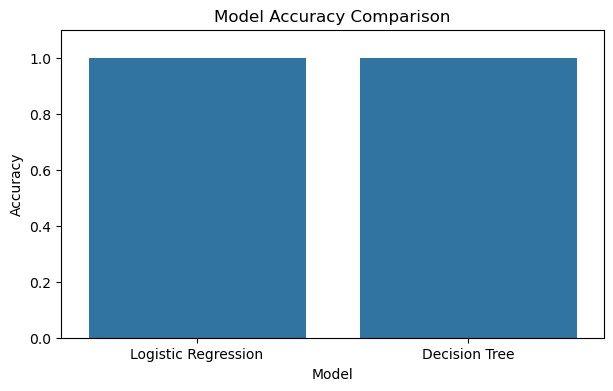

In [46]:
plt.figure(figsize=(7, 4))

sns.barplot(data=comparison, x="Model", y="Accuracy")

plt.ylim(0, 1.1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

## Conclusion

In this project, machine learning was used to predict whether a student would Pass or Fail based on study hours, attendance, previous score, and assignments completed.

Two classification algorithms were implemented:

- Logistic Regression
- Decision Tree

Both models achieved 100% accuracy on the test set and correctly classified all 4 test samples. Logistic Regression also achieved an AUC of 1.00.

The results demonstrate the basic machine learning workflow, including data preparation, train-test splitting, model training, prediction, and model evaluation using accuracy, confusion matrix, precision, recall, F1-score, ROC curve, and AUC.

However, the dataset used in this project is very small, with only 20 records. Therefore, the evaluation results should not be generalized to real-world student performance. A larger and more realistic dataset would be required for reliable conclusions.